# 05 — Taking a score apart, and what it still cannot tell you

A ranked list nobody can interrogate does not get used. An agent about to dial is entitled
to ask *why this lead*; a manager is entitled to ask *what is it leaning on overall*. Both
answers here are **model-agnostic**, so switching algorithms costs nothing but the
equation.

| # | Question | Answer |
|---|---|---|
| 1 | what does the model rely on? | many weak signals, no single one |
| 2 | why did *this* lead score that? | one-at-a-time ablation |
| 3 | what would change it? | response curves, inside the support |
| 4 | what does none of it answer? | who buys *because* we called |

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, ".")
from pe_style import *
from priority_engine import interpret
import joblib

bundle = joblib.load(ARTIFACTS / "notebook_model.joblib")   # written by notebook 03
pipe, reference = bundle["pipeline"], bundle["reference"]
fref = bundle.get("feature_ref")   # the population build() ranks this lead against
X_test, y_test = bundle["holdout"]["X"], bundle["holdout"]["y"]
full = leads_db()

print(f"model      {bundle['algorithm']}")
print(f"holdout    {len(y_test):,} rows")

model      logreg
holdout    9,380 rows


## 1. Globally: what does shuffling a column cost?

Permutation importance in PR-AUC. Each bar: *this much ranking ability is lost if the
column is replaced with noise.* Nothing about the model's internals is assumed.

               feature  importance      std   direction
    visited_offer_page    0.026164 0.002727          up
 has_previous_purchase    0.026029 0.002563          up
   offer_views_last_7d    0.009995 0.002489          up
incoming_call_last_24h    0.009511 0.001632          up
      discount_percent    0.007196 0.001082          up
               channel    0.004622 0.002333 categorical
 days_to_policy_expiry    0.004122 0.003635        down
          payment_type    0.002213 0.001067 categorical


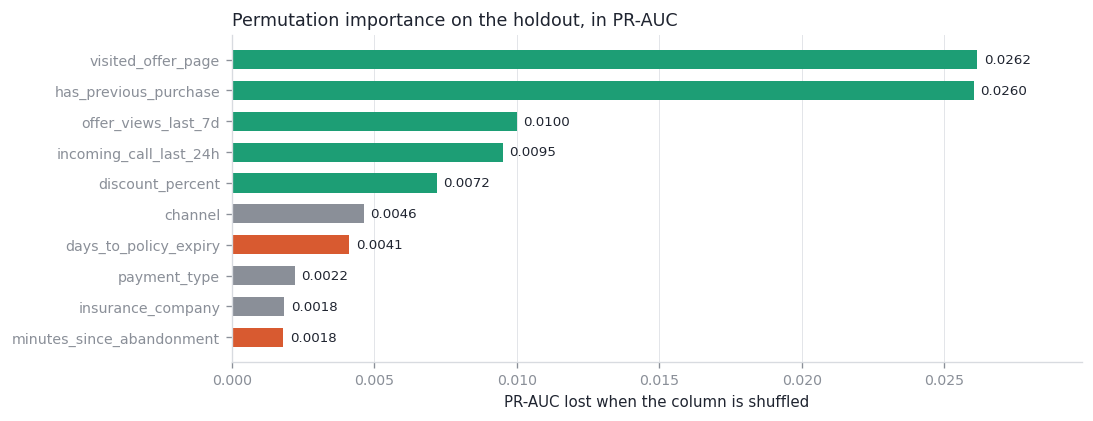

In [2]:
imp = pd.DataFrame(interpret.global_importance(pipe, X_test, y_test))
top = imp.nlargest(10, "importance").sort_values("importance")

fig, ax = plt.subplots(figsize=(9.2, 3.6))
colors = [TEAL if d == "up" else CORAL if d == "down" else MUTED
          for d in top.get("direction", ["flat"] * len(top))]
ax.barh(range(len(top)), top["importance"], color=colors, height=0.62)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top["feature"])
for i, v in enumerate(top["importance"]):
    ax.annotate(f"{v:.4f}", (v, i), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8)
ax.set_title("Permutation importance on the holdout, in PR-AUC")
ax.set_xlabel("PR-AUC lost when the column is shuffled")
ax.margins(x=0.14); ax.grid(axis="y", visible=False)
save(fig, "05_global_importance")

print(imp.nlargest(8, "importance").to_string(index=False))

No single feature dominates — the top two are worth a few thousandths of PR-AUC each and
the rest trail off gently.

**That is not a weak model, it is an accurate description of the problem:** the job is to
accumulate weak signals. A feature with implausible importance here would be the first
place to look for leakage.

## 2. Per lead: one-at-a-time ablation

Set one feature to the population reference, re-score, and measure how far the log-odds
moved. That shift is what the lead's own value was contributing.

baseline (every feature at the population reference)   7.76%
this lead                                              39.81%
unexplained by one-at-a-time ablation (interactions)    +1.1969 log-odds

                  feature   value reference  contribution
    has_previous_purchase       1       0.0        0.3103
   incoming_call_last_24h       1       0.0        0.3103
                   device desktop    mobile       -0.0576
                  partner shoraka    direct        0.0378
        insurance_company    Asia      Iran        0.0378
             payment_type    bnpl      cash        0.0378
minutes_since_abandonment      28      84.0        0.0378
    days_to_policy_expiry       5      13.0        0.0378


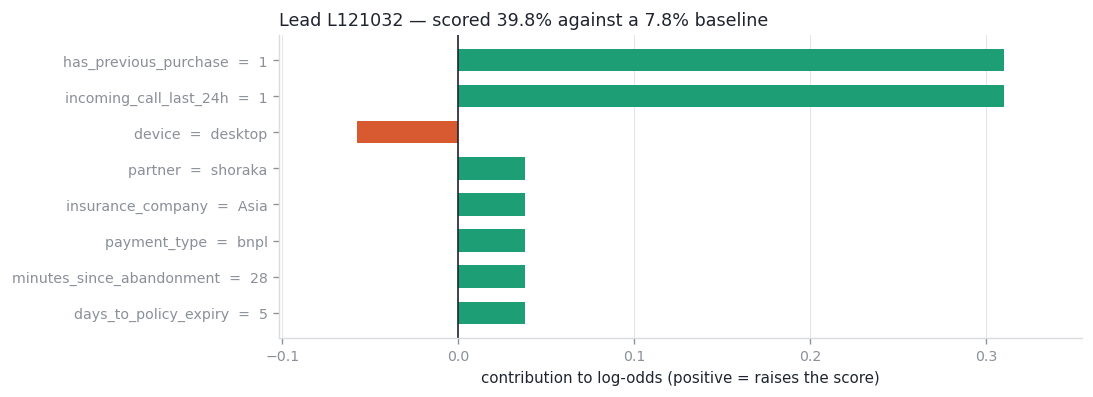

In [3]:
scores = pipe.predict_proba(X_test)[:, 1]
pick = bundle["test_rows"].iloc[[int(np.argsort(-scores)[3])]]["lead_id"].iloc[0]
lead = full[full["lead_id"] == pick]

ex = interpret.explain(pipe, lead, reference, fref, top_n=8)
c = pd.DataFrame(ex["contributions"]).iloc[::-1]

fig, ax = plt.subplots(figsize=(9.2, 3.4))
ax.barh(range(len(c)), c["contribution"],
        color=[TEAL if v > 0 else CORAL for v in c["contribution"]], height=0.62)
ax.axvline(0, lw=1, color=INK)
ax.set_yticks(range(len(c)))
ax.set_yticklabels([f"{r.feature}  =  {r.value}" for r in c.itertuples()], fontsize=8.5)
ax.set_title(f"Lead {pick} — scored {ex['probability']:.1%} against a {ex['base_probability']:.1%} baseline")
ax.set_xlabel("contribution to log-odds (positive = raises the score)")
ax.grid(axis="y", visible=False); ax.margins(x=0.12)
save(fig, "05_lead_breakdown")

print(f"baseline (every feature at the population reference)   {ex['base_probability']:.2%}")
print(f"this lead                                              {ex['probability']:.2%}")
print(f"unexplained by one-at-a-time ablation (interactions)    {ex['residual']:+.4f} log-odds")
print()
print(pd.DataFrame(ex["contributions"])[["feature", "value", "reference", "contribution"]]
      .to_string(index=False))

Deliberately **not** a Shapley value: one-at-a-time ablation cannot attribute interaction
effects, and the `residual` line prints exactly how much it failed to account for — the
honesty is in the output rather than in a footnote. That residual is large for this lead,
which is itself the finding: its score comes mostly from features acting *together*, not
from any one of them.

For someone deciding whether to dial, "above baseline mainly because they have bought
before and called in, with a young abandonment helping and the device pulling the other
way" is the useful answer, and it is the one this gives reliably.

## 3. Response curves: what would change this score?

One lead held completely fixed, one feature swept across the range the model was trained
on. Unlike the global chart, this is this lead's own behaviour.

/Users/hamed/workspace/priority-engine/src/priority_engine/interpret.py:182: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '16.608695652173914' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  probe.loc[i, feature] = v
/Users/hamed/workspace/priority-engine/src/priority_engine/interpret.py:182: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-16.52173913043478' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  probe.loc[i, feature] = v


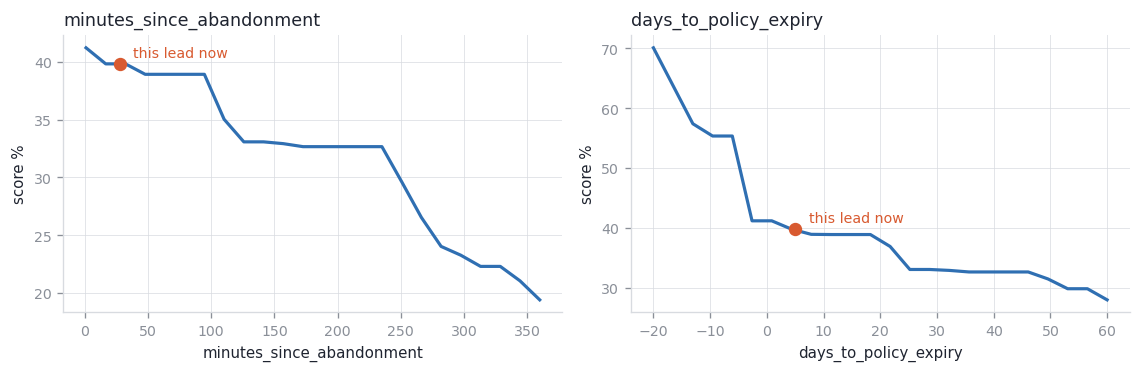

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2))
for ax, feat in zip(axes, ["minutes_since_abandonment", "days_to_policy_expiry"]):
    sw = interpret.sweep(pipe, lead, feat, fref)
    xs = [float(p["value"]) for p in sw["points"]]
    ys = [p["probability"] * 100 for p in sw["points"]]
    ax.plot(xs, ys, color=BLUE, lw=1.9)
    cur = float(sw["current"])
    ax.plot([cur], [ex["probability"] * 100], "o", ms=7, color=CORAL, zorder=3)
    ax.annotate("this lead now", (cur, ex["probability"] * 100), xytext=(8, 4),
                textcoords="offset points", fontsize=8.5, color=CORAL)
    ax.set_title(feat); ax.set_xlabel(feat); ax.set_ylabel("score %")
save(fig, "05_response_curves");

Read the abandonment curve carefully: it stops at 360 because that is where the training
data stops. Sweeping past it would produce a line, but not evidence — the same boundary
notebook 04 builds the serving path around.

## 4. The limit interpretation cannot fix

Everything above explains **who is likely to buy**. The floor wants **who buys *because we
called***. Different quantities, and no attribution on this dataset converts one into the
other.

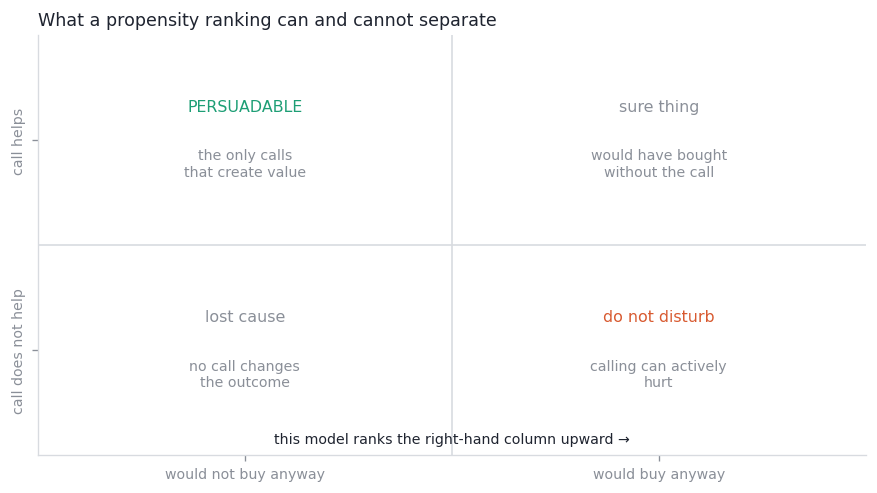

In [5]:
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.axhline(0.5, lw=1, color=GRID); ax.axvline(0.5, lw=1, color=GRID)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xticks([0.25, 0.75]); ax.set_xticklabels(["would not buy anyway", "would buy anyway"])
ax.set_yticks([0.25, 0.75]); ax.set_yticklabels(["call does not help", "call helps"], rotation=90, va="center")
ax.grid(False)

quadrants = [
    (0.25, 0.75, "PERSUADABLE", "the only calls\nthat create value", TEAL),
    (0.75, 0.75, "sure thing", "would have bought\nwithout the call", MUTED),
    (0.25, 0.25, "lost cause", "no call changes\nthe outcome", MUTED),
    (0.75, 0.25, "do not disturb", "calling can actively\nhurt", CORAL),
]
for x, y, title, sub, c in quadrants:
    ax.annotate(title, (x, y + 0.07), ha="center", fontsize=9.5, color=c, weight="medium")
    ax.annotate(sub, (x, y - 0.02), ha="center", va="top", fontsize=8.5, color=MUTED)

ax.annotate("this model ranks the right-hand column upward →", (0.5, 0.03),
            ha="center", fontsize=8.5, color=INK)
ax.set_title("What a propensity ranking can and cannot separate")
save(fig, "05_uplift_quadrant");

Ranking by propensity pushes the whole right-hand column up the queue — including the
sure things, where the call was never needed — and it cannot see the bottom-right quadrant
at all.

The reason is concrete: **there is no outbound-call column.** `incoming_call_last_24h` is
*inbound* — the customer's intent, not our treatment. A model cannot estimate the effect
of an action it has never observed.

**The fix is data, not modelling:** withhold calls from a small random slice of the queue,
and the difference between called and withheld becomes a measurement of uplift. Highest-
value next step in the project.

## Series map

| Notebook | Question it answers |
|---|---|
| `01_eda` | what the columns are, what is missing, what correlates with what |
| `02_record_generation` | how a row was written, and what that decides about the two clocks |
| `03_model_selection` | why the split is temporal and three-way, which model, and what it had to beat |
| `04_serving_and_decay` | how a score stays current without re-running the model forever |
| `05_interpretation` | why this lead, and what the ranking still cannot tell you |